# Presentation: Data Exploration Slides
Two slides worth of visuals and text:
- **Slide 1**: TorNet dataset overview
- **Slide 2**: MADIS surface weather data

In [118]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

import sys
sys.path.append('../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

TORNET_ROOT = os.environ.get('TORNET_ROOT', '../tornet_data')
COLORS = {'TOR': '#d62728', 'WRN': '#ff7f0e', 'NUL': '#1f77b4'}

---
# Slide 1: TorNet Dataset

In [119]:
catalog = pd.read_csv(f'{TORNET_ROOT}/catalog.csv', low_memory=False, parse_dates=['start_time'])
print(f'Total radar samples: {len(catalog):,}')
print(f'Unique storm events: {catalog["event_id"].nunique():,}')
print(f'Years covered: {catalog["start_time"].dt.year.min()} – {catalog["start_time"].dt.year.max()}')
print(f'Radar sites: {catalog["site_name"].nunique():,} WSR-88D stations')
print()
print('Sample breakdown:')
counts = catalog['category'].value_counts()
for cat, n in counts.items():
    print(f'  {cat}: {n:,} ({100*n/len(catalog):.1f}%)')

Total radar samples: 203,133
Unique storm events: 23,755
Years covered: 2013 – 2022
Radar sites: 142 WSR-88D stations

Sample breakdown:
  NUL: 124,766 (61.4%)
  WRN: 64,510 (31.8%)
  TOR: 13,857 (6.8%)


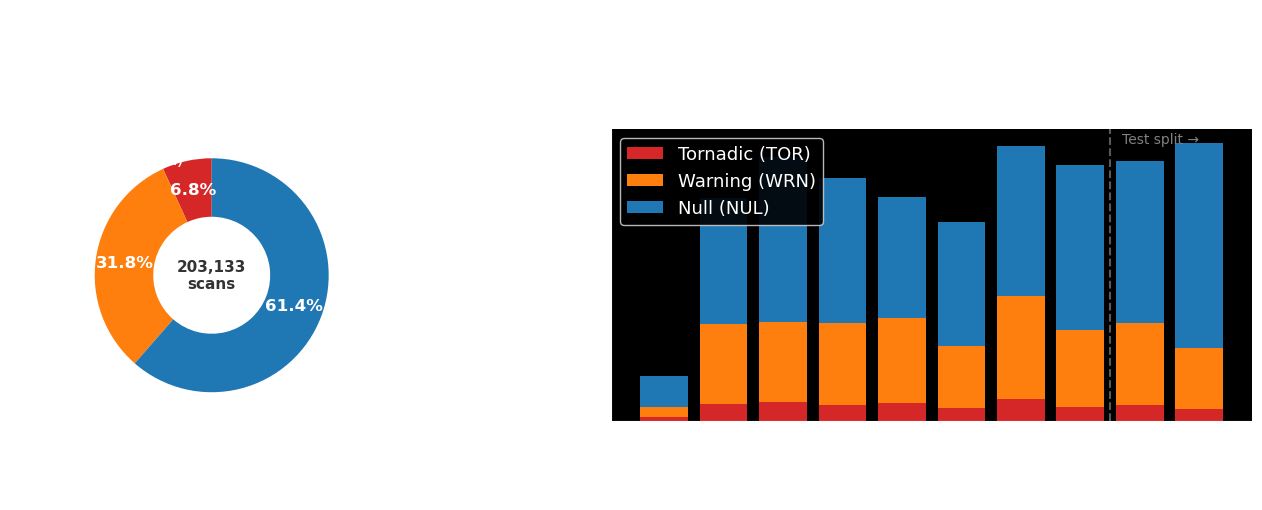

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Class distribution donut chart ──
ax = axes[0]
counts = catalog['category'].value_counts().reindex(['TOR', 'WRN', 'NUL'])
labels = ['Tornadic\n(TOR)', 'Warning\n(WRN)', 'Null\n(NUL)']
colors = [COLORS['TOR'], COLORS['WRN'], COLORS['NUL']]
wedges, texts, autotexts = ax.pie(
    counts, labels=labels, colors=colors, autopct='%1.1f%%',
    startangle=90, wedgeprops=dict(width=0.5), pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
    at.set_color('white')
ax.set_title('Sample Distribution\n(203,133 total radar scans)', fontweight='bold')
ax.text(0, 0, f'{len(catalog):,}\nscans', ha='center', va='center', fontsize=11, fontweight='bold', color='#333')

# ── Right: Samples per year stacked bar ──
ax = axes[1]
year_cat = catalog.groupby([catalog['start_time'].dt.year, 'category']).size().unstack(fill_value=0)
year_cat = year_cat.reindex(columns=['TOR', 'WRN', 'NUL'])
years = year_cat.index
bottom_wrn = year_cat['TOR'].values
bottom_nul = bottom_wrn + year_cat['WRN'].values

ax.bar(years, year_cat['TOR'], color=COLORS['TOR'], label='Tornadic (TOR)')
ax.bar(years, year_cat['WRN'], bottom=bottom_wrn, color=COLORS['WRN'], label='Warning (WRN)')
ax.bar(years, year_cat['NUL'], bottom=bottom_nul, color=COLORS['NUL'], label='Null (NUL)')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Radar Scans')
ax.set_title('Radar Scans per Year by Category', fontweight='bold')
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(loc='upper left', framealpha=0.9)
ax.axvline(x=2020.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(2020.7, ax.get_ylim()[1]*0.95, 'Test split →', fontsize=10, color='gray')

plt.suptitle('TorNet: Polarimetric Radar Dataset for Tornado Detection', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('slide1_tornet_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Radar scan examples: Tornadic vs Non-Tornadic
Load one EF3+ tornadic sample and one null sample from the test set and plot all 6 radar variables side by side.

In [121]:
from tornet.data.keras.loader import KerasDataLoader
from tornet.display.display import plot_radar

# ── Load one EF3+ tornadic sample ──
catalog_tor = pd.read_csv(f'{TORNET_ROOT}/catalog.csv', low_memory=False, parse_dates=['start_time'])
catalog_tor = catalog_tor[catalog_tor['ef_number'] >= 3]

ds_tor = KerasDataLoader(
    data_root=TORNET_ROOT,
    data_type='test',
    random_state=42,
    catalog=catalog_tor,
    batch_size=1,
)
batch_tor = ds_tor[0]
x_tor = batch_tor[0]
y_tor = batch_tor[1]
print(f'Loaded tornadic sample — label: {np.squeeze(y_tor)}')
print(f'DBZ shape: {x_tor["DBZ"].shape}')  # (1, az, range, tilts)

# ── Load one null sample ──
catalog_nul = pd.read_csv(f'{TORNET_ROOT}/catalog.csv', low_memory=False, parse_dates=['start_time'])
catalog_nul = catalog_nul[catalog_nul['ef_number'] == -1]

ds_nul = KerasDataLoader(
    data_root=TORNET_ROOT,
    data_type='test',
    random_state=42,
    catalog=catalog_nul,
    batch_size=1,
)
batch_nul = ds_nul[0]
x_nul = batch_nul[0]
y_nul = batch_nul[1]
print(f'Loaded null sample — label: {np.squeeze(y_nul)}')

Loaded tornadic sample — label: 1
DBZ shape: (1, 120, 240, 2)
Loaded null sample — label: 0


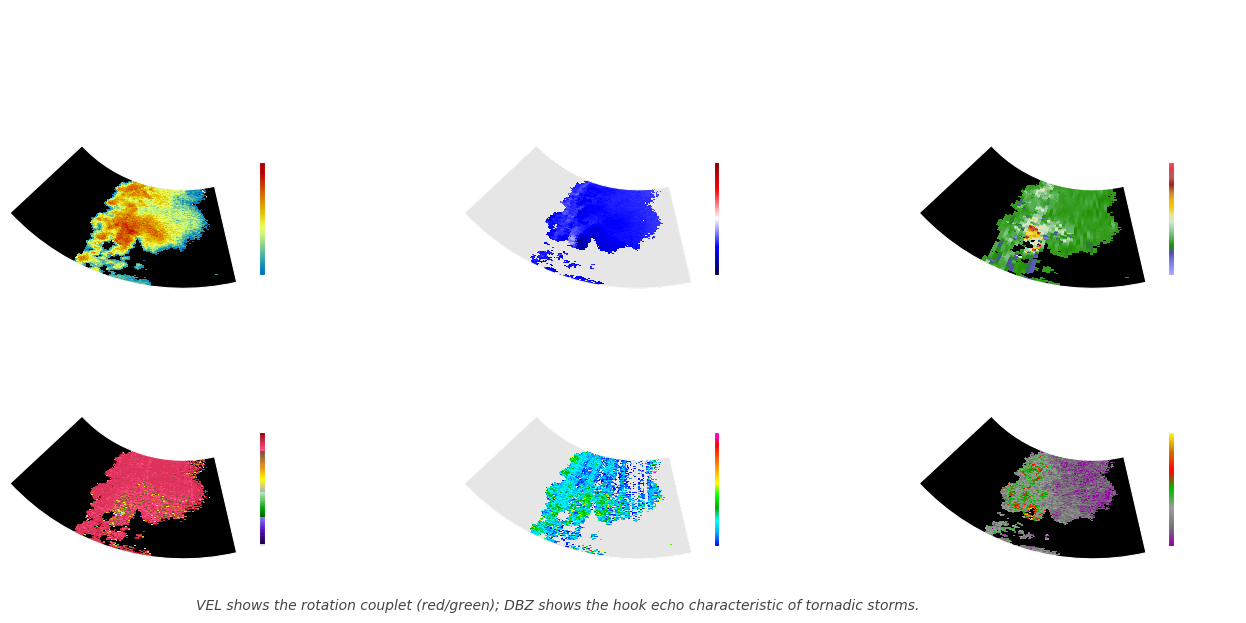

In [122]:
vars_to_plot = ['DBZ', 'VEL', 'KDP', 'RHOHV', 'ZDR', 'WIDTH']

# ── Tornadic scan — all 6 variables ──
fig = plt.figure(figsize=(14, 6), facecolor='white')
plot_radar(x_tor, fig=fig, channels=vars_to_plot, include_cbar=True, time_idx=0, n_rows=2, n_cols=3)
fig.suptitle('Tornadic Event (EF3+) — All 6 Dual-Pol Radar Variables', fontsize=15, fontweight='bold', y=1.02)
fig.text(0.5, 0.02,
    'VEL shows the rotation couplet (red/green); DBZ shows the hook echo characteristic of tornadic storms.',
    ha='center', fontsize=10, color='#444', style='italic')
plt.tight_layout()
plt.savefig('slide1_radar_tor.png', dpi=150, bbox_inches='tight')
plt.show()

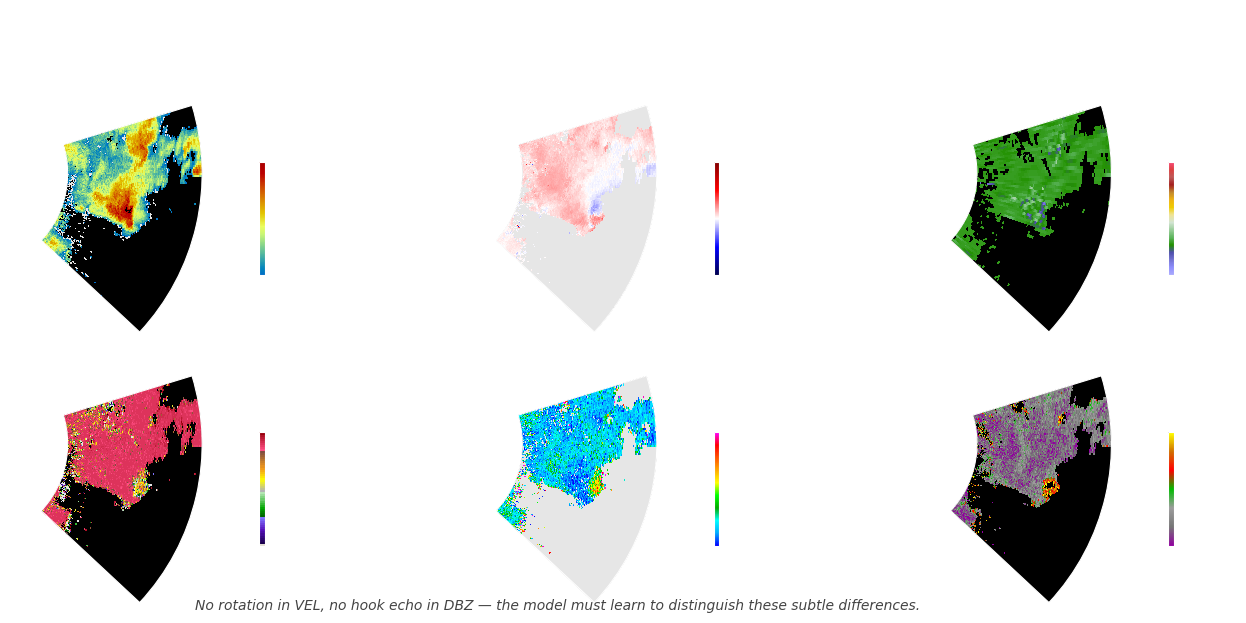

In [123]:
# ── Null scan — all 6 variables ──
fig = plt.figure(figsize=(14, 6), facecolor='white')
plot_radar(x_nul, fig=fig, channels=vars_to_plot, include_cbar=True, time_idx=0, n_rows=2, n_cols=3)
fig.suptitle('Non-Tornadic Event (Null) — All 6 Dual-Pol Radar Variables', fontsize=15, fontweight='bold', y=1.02)
fig.text(0.5, 0.02,
    'No rotation in VEL, no hook echo in DBZ — the model must learn to distinguish these subtle differences.',
    ha='center', fontsize=10, color='#444', style='italic')
plt.tight_layout()
plt.savefig('slide1_radar_nul.png', dpi=150, bbox_inches='tight')
plt.show()

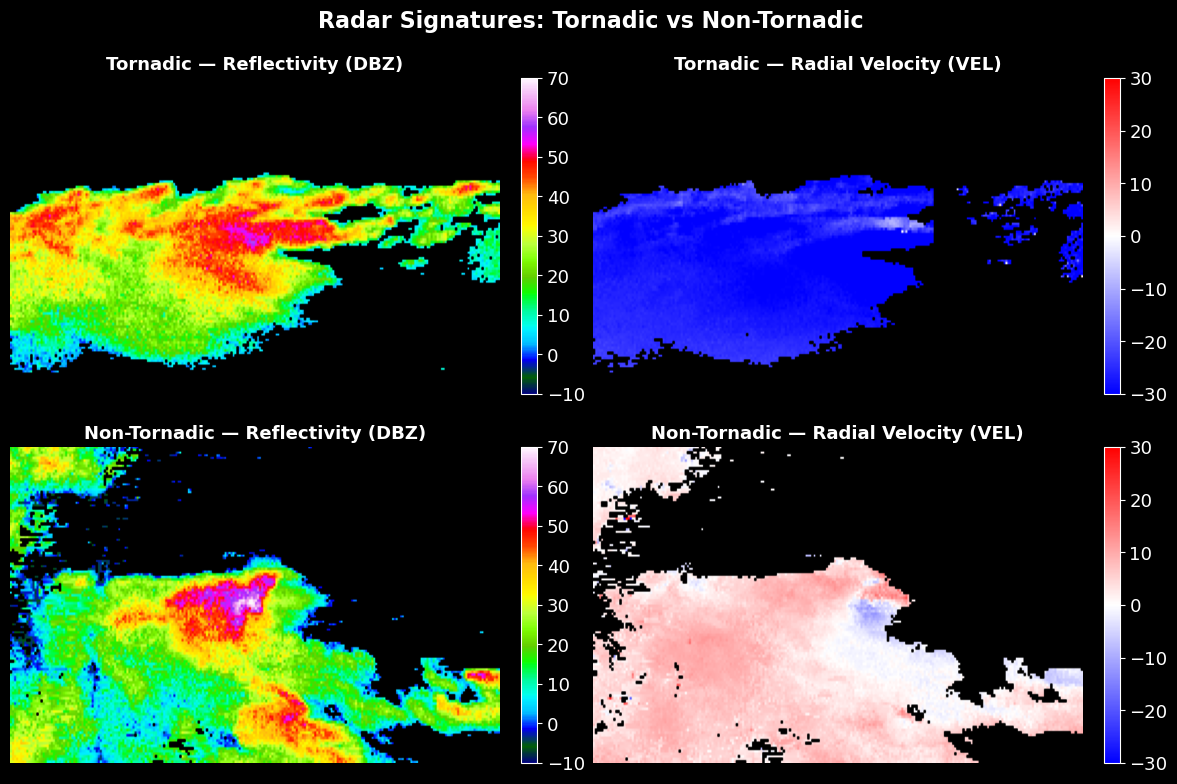

In [124]:
# ── Side-by-side DBZ + VEL only (cleaner for a single slide) ──
fig, axes = plt.subplots(2, 2, figsize=(12, 8), facecolor='black')

def plot_single_var(ax, x, var, title, cmap, vmin, vmax):
    data = x[var][0, :, :, 0]  # first sample, first tilt
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
    ax.set_title(title, color='white', fontsize=13, fontweight='bold', pad=6)
    ax.axis('off')
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.yaxis.set_tick_params(color='white', labelcolor='white')
    return im

plot_single_var(axes[0, 0], x_tor, 'DBZ', 'Tornadic — Reflectivity (DBZ)', 'gist_ncar', -10, 70)
plot_single_var(axes[0, 1], x_tor, 'VEL', 'Tornadic — Radial Velocity (VEL)', 'bwr', -30, 30)
plot_single_var(axes[1, 0], x_nul, 'DBZ', 'Non-Tornadic — Reflectivity (DBZ)', 'gist_ncar', -10, 70)
plot_single_var(axes[1, 1], x_nul, 'VEL', 'Non-Tornadic — Radial Velocity (VEL)', 'bwr', -30, 30)

fig.suptitle('Radar Signatures: Tornadic vs Non-Tornadic', color='white', fontsize=16, fontweight='bold')
fig.patch.set_facecolor('black')
plt.tight_layout()
plt.savefig('slide1_radar_comparison.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

In [125]:
# Radar variable reference table — for slide text
radar_vars = pd.DataFrame([
    ('DBZ',   'Reflectivity',              'Rain/hail intensity — hook echo visible in tornadic storms'),
    ('VEL',   'Radial Velocity',           'Wind speed toward/away from radar — rotation couplet indicates tornado'),
    ('KDP',   'Differential Phase',        'Rainfall rate; distinguishes rain from hail'),
    ('RHOHV', 'Correlation Coefficient',   'Particle uniformity — debris signature drops near tornado'),
    ('ZDR',   'Differential Reflectivity', 'Particle shape — large oblate drops have high ZDR'),
    ('WIDTH', 'Spectrum Width',            'Turbulence within a radar cell — elevated near mesocyclone'),
], columns=['Variable', 'Name', 'What it measures'])
print(radar_vars.to_string(index=False))

Variable                      Name                                                       What it measures
     DBZ              Reflectivity             Rain/hail intensity — hook echo visible in tornadic storms
     VEL           Radial Velocity Wind speed toward/away from radar — rotation couplet indicates tornado
     KDP        Differential Phase                            Rainfall rate; distinguishes rain from hail
   RHOHV   Correlation Coefficient              Particle uniformity — debris signature drops near tornado
     ZDR Differential Reflectivity                      Particle shape — large oblate drops have high ZDR
   WIDTH            Spectrum Width             Turbulence within a radar cell — elevated near mesocyclone


---
# Slide 2: MADIS Surface Weather Data

In [126]:
madis = pd.read_csv(f'{TORNET_ROOT}/madis_features_clean.csv', low_memory=False)
eligible = pd.read_csv(f'{TORNET_ROOT}/catalog_madis_eligible.csv', low_memory=False)

print(f'MADIS-eligible radar scans: {len(eligible):,} / {len(catalog):,} ({100*len(eligible)/len(catalog):.1f}% of TorNet)')
print(f'Unique storms with MADIS coverage: {madis["storm_id"].nunique():,}')
print()
features = ['pressure', 'wind_gust', 'pressure_anomaly_24h', 'wind_anomaly_24h', 'instability_proxy_T2h', 'instability_proxy_T0']
print('Feature coverage:')
for f in features:
    pct = madis[f].notna().mean() * 100
    print(f'  {f}: {pct:.1f}% non-null')

MADIS-eligible radar scans: 105,108 / 203,133 (51.7% of TorNet)
Unique storms with MADIS coverage: 16,660

Feature coverage:
  pressure: 100.0% non-null
  wind_gust: 100.0% non-null
  pressure_anomaly_24h: 98.0% non-null
  wind_anomaly_24h: 98.9% non-null
  instability_proxy_T2h: 98.1% non-null
  instability_proxy_T0: 98.1% non-null


In [127]:
def cohens_d(group1, group2):
    g1, g2 = group1.dropna(), group2.dropna()
    pooled_std = np.sqrt((g1.std()**2 + g2.std()**2) / 2)
    return (g1.mean() - g2.mean()) / pooled_std

tor = madis[madis['category'] == 'TOR']
nul = madis[madis['category'] == 'NUL']

feature_labels = {
    'pressure':              'Pressure (raw)',
    'wind_gust':             'Wind Gust (raw)',
    'instability_proxy_T0':  'Instability Proxy T0\n(T − Td at event time)',
    'wind_anomaly_24h':      'Wind Anomaly 24h\n(wind change over 24h)',
    'instability_proxy_T2h': 'Instability Proxy T−2h\n(T − Td 2h before)',
    'pressure_anomaly_24h':  'Pressure Anomaly 24h\n(pressure drop over 24h)',
}

d_values = {f: abs(cohens_d(tor[f], nul[f])) for f in features}
d_series = pd.Series(d_values).sort_values()

for f, d in d_values.items():
    print(f'{f}: d = {d:.3f}')

pressure: d = 0.627
wind_gust: d = 0.166
pressure_anomaly_24h: d = 0.538
wind_anomaly_24h: d = 0.228
instability_proxy_T2h: d = 0.585
instability_proxy_T0: d = 0.477


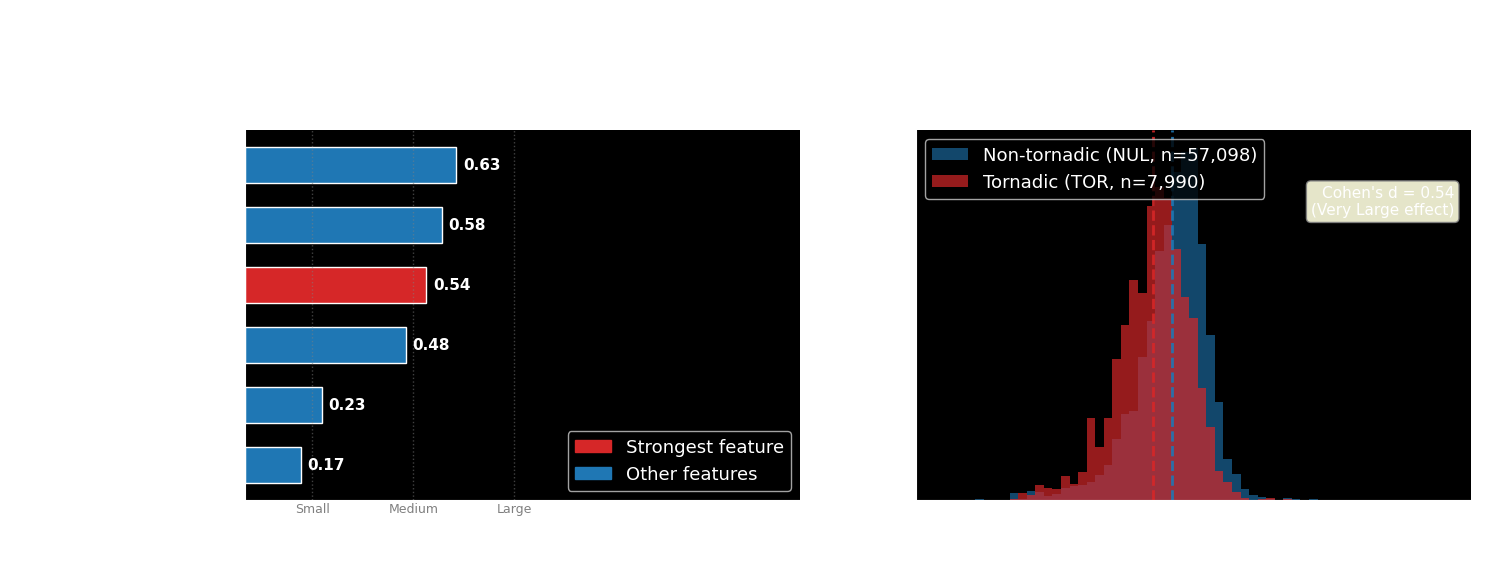

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ── Left: Cohen's d bar chart ──
ax = axes[0]
bar_colors = ['#d62728' if f == 'pressure_anomaly_24h' else '#1f77b4' for f in d_series.index]
bars = ax.barh(
    [feature_labels[f] for f in d_series.index],
    d_series.values, color=bar_colors, edgecolor='white', height=0.6,
)
for bar, val in zip(bars, d_series.values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=11, fontweight='bold')
for thresh, label in [(0.2, 'Small'), (0.5, 'Medium'), (0.8, 'Large')]:
    ax.axvline(x=thresh, color='gray', linestyle=':', alpha=0.5, linewidth=1)
    ax.text(thresh, -0.8, label, ha='center', color='gray', fontsize=9)
ax.set_xlabel("Cohen's d  (effect size: TOR vs NUL)")
ax.set_title('MADIS Feature Predictive Power\n(higher = stronger tornado signal)', fontweight='bold')
ax.set_xlim(0, 1.65)
red_patch = mpatches.Patch(color='#d62728', label='Strongest feature')
blue_patch = mpatches.Patch(color='#1f77b4', label='Other features')
ax.legend(handles=[red_patch, blue_patch], loc='lower right')

# ── Right: Pressure anomaly distribution TOR vs NUL ──
ax = axes[1]
tor_vals = tor['pressure_anomaly_24h'].dropna()
nul_vals = nul['pressure_anomaly_24h'].dropna()
bins = np.linspace(-4000, 4000, 60)
ax.hist(nul_vals, bins=bins, alpha=0.6, color=COLORS['NUL'], label=f'Non-tornadic (NUL, n={len(nul_vals):,})', density=True)
ax.hist(tor_vals, bins=bins, alpha=0.7, color=COLORS['TOR'], label=f'Tornadic (TOR, n={len(tor_vals):,})', density=True)
ax.axvline(nul_vals.mean(), color=COLORS['NUL'], linestyle='--', linewidth=2, alpha=0.9)
ax.axvline(tor_vals.mean(), color=COLORS['TOR'], linestyle='--', linewidth=2, alpha=0.9)
ax.set_xlabel('Pressure Change over 24h (Pa)')
ax.set_ylabel('Density')
ax.set_title('Pressure Anomaly (24h): Tornadic vs Non-Tornadic', fontweight='bold')
ax.legend()
ax.text(0.97, 0.85,
        f"Cohen's d = {d_values['pressure_anomaly_24h']:.2f}\n(Very Large effect)",
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray', alpha=0.9),
        fontsize=11)

plt.suptitle('MADIS: Surface Weather Station Data (APRSWXNET)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('slide2_madis_overview.png', dpi=150, bbox_inches='tight')
plt.show()

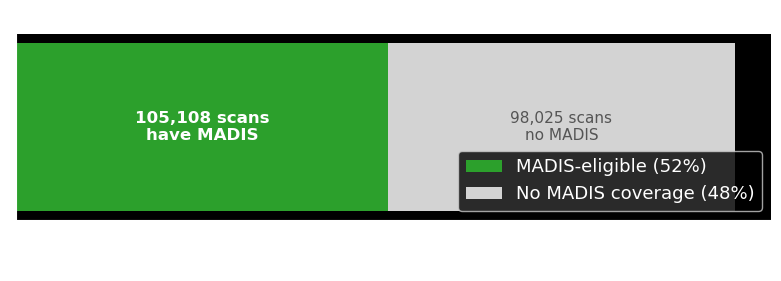

In [129]:
# Coverage bar
fig, ax = plt.subplots(figsize=(8, 3))
n_total = len(catalog)
n_eligible = len(eligible)
n_no_madis = n_total - n_eligible

ax.barh([''], [n_eligible], color='#2ca02c', label=f'MADIS-eligible ({100*n_eligible/n_total:.0f}%)')
ax.barh([''], [n_no_madis], left=[n_eligible], color='#d3d3d3', label=f'No MADIS coverage ({100*n_no_madis/n_total:.0f}%)')
ax.text(n_eligible/2, 0, f'{n_eligible:,} scans\nhave MADIS', ha='center', va='center',
        fontweight='bold', fontsize=12, color='white')
ax.text(n_eligible + n_no_madis/2, 0, f'{n_no_madis:,} scans\nno MADIS', ha='center', va='center',
        fontsize=11, color='#555')
ax.set_xlabel('Number of Radar Scans')
ax.set_title('MADIS Coverage across TorNet Dataset', fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(loc='lower right')
ax.set_yticks([])
plt.tight_layout()
plt.savefig('slide2_madis_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

In [130]:
# Feature description table
madis_features = pd.DataFrame([
    ('pressure',              'Raw T0',    'Barometric pressure at event time (Pa)'),
    ('wind_gust',             'Raw T0',    'Peak wind gust at event time (m/s)'),
    ('pressure_anomaly_24h',  'Engineered','Pressure drop vs 24h prior — captures rapid deepening'),
    ('wind_anomaly_24h',      'Engineered','Wind change vs 24h prior'),
    ('instability_proxy_T2h', 'Engineered','Temp − Dewpoint 2h before — atmospheric instability'),
    ('instability_proxy_T0',  'Engineered','Temp − Dewpoint at event time'),
], columns=['Feature', 'Type', 'Description'])
print('=== MADIS Features Used in Model ===')
print(madis_features.to_string(index=False))

=== MADIS Features Used in Model ===
              Feature       Type                                           Description
             pressure     Raw T0                Barometric pressure at event time (Pa)
            wind_gust     Raw T0                    Peak wind gust at event time (m/s)
 pressure_anomaly_24h Engineered Pressure drop vs 24h prior — captures rapid deepening
     wind_anomaly_24h Engineered                              Wind change vs 24h prior
instability_proxy_T2h Engineered   Temp − Dewpoint 2h before — atmospheric instability
 instability_proxy_T0 Engineered                         Temp − Dewpoint at event time
